# LLM Federated Finetuning with PEFT and Quantization

## Overview

This tutorial demonstrates how to efficiently fine-tune Microsoft's Phi-4 model (7B parameter variant) in a federated learning workflow using OpenFL framework with advanced techniques for memory optimization and performance enhancement. The approach combines:

### Memory Optimization Techniques
- **Parameter-Efficient Fine-Tuning (PEFT)**: Using Low-Rank Adaptation (LoRA) to fine-tune only a small subset of model parameters
- **Quantization**: Comparing 4-bit (NF4) and 8-bit quantization approaches with QLoRA to reduce memory footprint
- **Gradient Checkpointing**: Trading computation for memory by recomputing activations during backpropagation

### Training Enhancements
- **Partial Round Updates**: Breaking each global round into partial updates for more frequent knowledge sharing
- **Fixed Training Steps**: Using a fixed number of training steps (100) equivalent to one epoch
- **Optimizer State Preservation**: Maintaining optimizer momentum across federation rounds
- **Memory Usage Tracking**: Detailed monitoring of GPU/CPU memory consumption across training phases

### Federated Learning Architecture
- **Server-Client Model**: Central aggregator and multiple collaborators (simulated locally)
- **Federated Averaging**: Weighted parameter averaging between collaborator models
- **Metrics Visualization**: Tracking and comparing training loss, validation loss, and memory usage

The tutorial implements a complete workflow that addresses common challenges in federated fine-tuning of large language models, including memory constraints, training efficiency, and performance metrics tracking across heterogeneous clients.

Before running the notebook make sure to install NVIDIA drivers using the below command
```
sudo apt update 
sudo apt install -y nvidia-driver-550 
sudo reboot
```

## Installation

In [1]:
!pip install torch transformers peft datasets trl==0.12.2 bitsandbytes accelerate -q

## Import Libraries

In [3]:
!pip install seaborn matplotlib pandas -q

In [4]:
import os
import torch
from transformers import (
    AutoModelForCausalLM,
    AutoTokenizer,
    BitsAndBytesConfig,
    TrainingArguments
)
from peft import (
    LoraConfig,
    get_peft_model,
    prepare_model_for_kbit_training,
    PeftModel
)
from peft.utils import get_peft_model_state_dict, set_peft_model_state_dict  # Added this import
from datasets import load_dataset
from trl import SFTTrainer
from openfl.experimental.workflow.interface import Aggregator, Collaborator, FLSpec
from openfl.experimental.workflow.placement import aggregator, collaborator
from openfl.experimental.workflow.runtime import LocalRuntime
import numpy as np
from transformers.trainer_callback import PrinterCallback
import transformers
import gc
import psutil

# Import our utility functions
from openfl.utilities.phi_utils import (
    get_gpu_memory_info,
    MemoryTracker,
    plot_memory_metrics,
    plot_loss_metrics,
    plot_aggregated_metrics
)

/home/azureuser/env_name/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2025-05-21 08:21:48,953	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [5]:
# Memory optimization setup
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
os.environ["TRANSFORMERS_ATTN_IMPLEMENTATION"] = "flash_attention_2"

def clear_gpu():
    torch.cuda.empty_cache()
    gc.collect()

clear_gpu()

## Acquiring and preprocessing dataset
We can download the dataset directly from the [LLM-Adapters repository](https://github.com/AGI-Edgerunners/LLM-Adapters)

In [6]:
# Import libraries needed for downloading and verifying the dataset
import hashlib
import requests

def file_checksum(file_path, algorithm="sha256"):
    """
    Calculate the checksum of a file using the specified hashing algorithm.
    
    Args:
        file_path (str): The path to the file for which the checksum is to be calculated.
        algorithm (str): The hashing algorithm to use (default is 'sha256').
    
    Returns:
        str: The calculated checksum of the file.
    """
    hash_func = hashlib.new(algorithm)
    with open(file_path, "rb") as f:
        for chunk in iter(lambda: f.read(4096), b""):
            hash_func.update(chunk)
    return hash_func.hexdigest()


# Download the dataset if it doesn't exist locally
if not os.path.exists("math_10k.json"):
    print("Downloading math_10k.json dataset...")
    r = requests.get(
        "https://raw.githubusercontent.com/AGI-Edgerunners/LLM-Adapters/main/ft-training_set/math_10k.json",
    )
    with open(
        "math_10k.json",
        "wb",
    ) as f:
        f.write(r.content)
    print("Download complete.")

    # Verify the integrity of the downloaded file
    actual_checksum = file_checksum("math_10k.json")
    expected_checksum = "0342d0d860ad8592b579329337c90e42eefd3d9f2898043140cbd120630418b8"
    if actual_checksum != expected_checksum:
        raise ValueError(
            "Checksum verification failed. The file may have been altered."
        )
    print("Checksum verification successful.")
else:
    print("Dataset already exists locally.")

# Set the dataset path to be used later
dataset_name = "math_10k.json"

Dataset already exists locally.


## Configuration

In [7]:
# Model and dataset
model_name = "microsoft/phi-4"
dataset_name = "math_10k.json"

# 4-bit QLoRA configuration
bnb_config_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,  # Enable double quantization for further memory saving
)

# 8-bit QLoRA configuration with more aggressive memory savings
bnb_config_8bit = BitsAndBytesConfig(
    load_in_8bit=True,
    llm_int8_enable_fp32_cpu_offload=True,
    llm_int8_skip_modules=['lm_head'],
    llm_int8_threshold=6.0,
    llm_int8_has_fp16_weight=False,
)

# Active quantization config (will be set to either 4-bit or 8-bit)
bnb_config = bnb_config_4bit  # Default to 4-bit

# LoRA configuration - reduce parameters to save memory
peft_config = LoraConfig(
    r=4,  # Reduced from 8 to save memory
    lora_alpha=16,
    lora_dropout=0.01,
    bias="none",
    task_type="CAUSAL_LM",
    target_modules="all-linear",
)

# Training configuration with memory optimizations
training_args = TrainingArguments(
    output_dir="./results",
    # Reduced steps for testing
    max_steps=50,  # Reduced from 100 to 50 to save memory
    per_device_train_batch_size=1,
    per_device_eval_batch_size=1,
    gradient_accumulation_steps=8,  # Increased from 4 to 8 to reduce memory pressure
    optim="adamw_torch_fused",
    # More frequent saving and logging
    save_steps=25,
    logging_steps=5,
    learning_rate=3e-4,
    weight_decay=0.001,
    fp16=False,
    bf16=True,
    max_grad_norm=0.5,
    warmup_ratio=0.02,
    lr_scheduler_type="cosine",
    gradient_checkpointing=True,
    report_to="none",
    # Enable memory optimization options
    deepspeed=None,  # Not using DeepSpeed but enabling other memory optimizations
    optim_target_modules=["c_attn", "c_proj"],  # Optimize specific modules
    # Add auto memory optimization flag
    auto_find_batch_size=True  # Automatically find the largest batch size that fits in memory
)

## Load and Prepare Model

In [8]:
# Load tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

# Load model with quantization
model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto",
    trust_remote_code=True
)

# Prepare model for k-bit training
model = prepare_model_for_kbit_training(model, use_gradient_checkpointing=True)

# Apply LoRA
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()

Loading checkpoint shards: 100%|██████████| 6/6 [00:04<00:00,  1.31it/s]


trainable params: 13,926,400 || all params: 14,673,433,600 || trainable%: 0.0949


## Load and Prepare Dataset

In [9]:
def format_prompt(example):
    if example["input"]:
        return f"""Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
{example['instruction']}

### Input:
{example['input']}

### Response:
{example['output']}"""
    else:
        return f"""Below is an instruction that describes a task. Write a response that appropriately completes the request.

### Instruction:
{example['instruction']}

### Response:
{example['output']}"""

# Load dataset
dataset = load_dataset("json", data_files=dataset_name, split="train", num_proc=4)
dataset = dataset.map(lambda x: {"text": format_prompt(x)}, num_proc=4)

# Split dataset
dataset = dataset.train_test_split(test_size=0.1)
train_dataset = dataset["train"]
eval_dataset = dataset["test"]

## Enhanced Training with SFTTrainer

In [10]:
# Create SFTTrainer
trainer = SFTTrainer(
    model=model,
    train_dataset=train_dataset,
    eval_dataset=eval_dataset,
    peft_config=peft_config,
    dataset_text_field="text",
    max_seq_length=512,  # Reduced from 1024 to save memory
    tokenizer=tokenizer,
    args=training_args
)

/home/azureuser/env_name/lib/python3.10/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': dataset_text_field, max_seq_length. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:328: UserWarning: You passed a `dataset_text_field` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
Map: 100%|██████████| 992/992 [00:00<00:00, 3267.10 examples/s]
max_steps is given, it will override any value given in num_train_epoc

## Federated Averaging Function

In [11]:
def FedAvg(peft_params, model, weights=None):
    """
    Perform Federated Averaging (FedAvg) on the model parameters.

    Parameters:
    peft_params (list): A list of state dictionaries containing the model parameters from different clients.
    model (torch.nn.Module): The model to which the averaged parameters will be applied.
    weights (list, optional): A list of weights for averaging the parameters. If None, equal weights are used.

    Returns:
    torch.nn.Module: The model with the averaged parameters applied.
    """
    state_dicts = peft_params
    state_dict = get_peft_model_state_dict(model)
    for key in peft_params[0]:
        dtype = state_dicts[0][key].dtype
        state_dict[key] = torch.from_numpy(
            np.average(
                [state[key].cpu().to(torch.float).numpy() for state in state_dicts], axis=0, weights=weights
            )
        ).to(dtype)
    set_peft_model_state_dict(model, state_dict)
    return model

## Federated Learning Workflow

In [12]:
# Import the required PrinterCallback for proper initialization/removal
from transformers.trainer_callback import PrinterCallback
import transformers
import gc
import psutil
import os
import math
import time

class FederatedFlow(FLSpec):
    def __init__(self, model=None, optimizer=None, rounds=3, quant_type="4bit", **kwargs):
        """
        Initialize the class with the given model, optimizer, and training parameters.

        Parameters:
        model (torch.nn.Module, optional): The model to be used. If None, a ValueError is raised.
        optimizer (torch.optim.Optimizer, optional): The optimizer to be used.
        rounds (int, optional): The number of rounds for training or processing (default is 3).
        quant_type (str, optional): Quantization type, either "4bit" or "8bit".
        **kwargs: Additional keyword arguments to be passed to the superclass initializer.

        Raises:
        ValueError: If no model is provided.
        """
        super().__init__(**kwargs)
        if model is not None:
            self.model = model
            self.peft_params = get_peft_model_state_dict(self.model)
            self.optimizer = optimizer
        else:
            raise ValueError("No model inputted")

        self.rounds = rounds
        self.quant_type = quant_type
        # Initialize histories for tracking metrics over rounds
        self.average_loss_history = []
        self.agg_model_loss_history = []
        self.local_model_loss_history = []
        # Dictionary to store optimizer states for each collaborator
        self.optimizer_states = {}
        

    @aggregator
    def start(self):
        """
        Initialize the model and set up the collaborators for federated learning.

        This method performs the initial setup for the model, including setting the
        collaborators, initializing private variables, and starting the first round
        of the federated learning process.
        """
        print(f"Performing initialization for model with {self.quant_type} quantization")
        print(f"Using {self.rounds} main rounds with partial round updates")
        self.collaborators = self.runtime.collaborators
        self.current_round = 0
        self.current_sub_round = 0
        # Initialize dictionary to collect memory stats
        # Check if collaborators are objects with name attribute or strings
        if hasattr(self.collaborators[0], 'name'):
            collab_names = [c.name for c in self.collaborators]
        else:
            # If collaborators are already strings, use them directly
            collab_names = self.collaborators
        self.all_memory_stats = {collab: {} for collab in collab_names}
        # Initialize optimizer states dictionary for each collaborator
        self.optimizer_states = {collab: None for collab in collab_names}
        self.next(
            self.aggregated_model_validation,
            foreach="collaborators",
        )

    
    @collaborator
    def aggregated_model_validation(self):
        """
        Perform aggregated model validation for a collaborator.

        This method loads the model, applies the PEFT configuration, and evaluates
        the model using the provided training and evaluation datasets. The validation
        score is then stored and the next step in the process is triggered.
        """
        print(f"[Round {self.current_round}, Update {self.current_sub_round}] Performing aggregated model validation for collaborator {self.input} with {self.quant_type}")
        # Initialize memory tracker for this collaborator
        self.memory_tracker = MemoryTracker(self.input, self.quant_type)
        self.memory_tracker.reset_peak()
        
        # Choose quantization config based on quant_type
        if self.quant_type == "4bit":
            quant_config = bnb_config_4bit
        else:  # 8bit
            quant_config = bnb_config_8bit
        
        # Define device_map variable
        device_map = {"": torch.cuda.current_device()} if torch.cuda.is_available() else "cpu"
        try:
            self.model = AutoModelForCausalLM.from_pretrained(
                model_name,
                quantization_config=quant_config,
                device_map=device_map,
                trust_remote_code=True
            )
            self.memory_tracker.log("model_load")
        except ValueError:
            # Fallback to CPU if GPU memory is insufficient
            print(f"Falling back to CPU mode for {self.input}")
            self.model = AutoModelForCausalLM.from_pretrained(
                model_name,
                device_map="cpu",
                trust_remote_code=True
            )
            self.memory_tracker.log("model_load")
        
        self.model = prepare_model_for_kbit_training(self.model)
        self.model = get_peft_model(self.model, peft_config)
        set_peft_model_state_dict(self.model, self.peft_params)
        
        # Use fixed number of steps (max_steps) for each round
        steps_per_round = training_args.max_steps  # Use the hardcoded 100 steps
        
        # Create a custom TrainingArguments for this round
        self.round_args = TrainingArguments(
            output_dir=training_args.output_dir,
            max_steps=steps_per_round,  # Use fixed steps per round
            per_device_train_batch_size=training_args.per_device_train_batch_size,
            gradient_accumulation_steps=training_args.gradient_accumulation_steps,
            optim=training_args.optim,
            save_steps=steps_per_round // 2 or 1,  # More frequent saving
            logging_steps=5,
            learning_rate=training_args.learning_rate,
            weight_decay=training_args.weight_decay,
            fp16=training_args.fp16,
            bf16=training_args.bf16,
            max_grad_norm=training_args.max_grad_norm,
            warmup_ratio=training_args.warmup_ratio,
            lr_scheduler_type=training_args.lr_scheduler_type,
            gradient_checkpointing=training_args.gradient_checkpointing,
            report_to=training_args.report_to
        )
        
        print(f"[{self.input}] Training with {steps_per_round} steps")
        
        trainer = SFTTrainer(
            model=self.model,
            args=self.round_args,  # Use round specific args
            peft_config=peft_config,
            train_dataset=self.train_dataset,
            eval_dataset=self.eval_dataset,
            max_seq_length=1024,
            dataset_text_field="text",
            tokenizer=tokenizer,
            packing=True,
            data_collator=transformers.DataCollatorForSeq2Seq(
                tokenizer, pad_to_multiple_of=8, return_tensors="pt", padding=True
            ),
        )

        trainer.remove_callback(PrinterCallback)
        out = trainer.evaluate()
        self.agg_validation_score = out["eval_loss"]
        print(f"{self.input} evaluation loss: {self.agg_validation_score}")
        self.memory_tracker.log_loss(eval_loss=self.agg_validation_score)  # Log eval loss
        self.memory_tracker.update_peak()
        self.next(self.train)

    @collaborator
    def train(self):
        """
        Train the model for a collaborator with partial epoch updates.

        This method trains the model using the provided training dataset,
        but processes it in smaller chunks (partial epochs) to allow more
        frequent parameter sharing between collaborators.
        """
        self.memory_tracker.log("before_training")
        
        # Reduce steps for 8-bit quantization
        if self.quant_type == "8bit":
            max_steps = training_args.max_steps // 2  # Half the steps for 8-bit
        else:
            max_steps = training_args.max_steps
        
        # Define partial training args
        self.sub_round_args = TrainingArguments(
            output_dir=training_args.output_dir,
            max_steps=max_steps,
            per_device_train_batch_size=training_args.per_device_train_batch_size,
            gradient_accumulation_steps=training_args.gradient_accumulation_steps,
            optim=training_args.optim,
            save_steps=max_steps // 4,
            logging_steps=2,
            learning_rate=training_args.learning_rate,
            weight_decay=training_args.weight_decay,
            fp16=training_args.fp16,
            bf16=training_args.bf16,
            max_grad_norm=training_args.max_grad_norm,
            warmup_ratio=training_args.warmup_ratio,
            lr_scheduler_type=training_args.lr_scheduler_type,
            gradient_checkpointing=training_args.gradient_checkpointing,
            report_to=training_args.report_to,
            auto_find_batch_size=True  # Add auto batch size finding
        )
        
        # Create trainer instance with our custom training args
        trainer = SFTTrainer(
            model=self.model,
            args=self.sub_round_args,
            peft_config=peft_config,
            train_dataset=self.train_dataset,
            eval_dataset=self.eval_dataset,
            max_seq_length=512,  # Reduced sequence length
            dataset_text_field="text",
            tokenizer=tokenizer,
        )
        
        # Make sure optimizer is initialized before training
        if not hasattr(trainer, 'optimizer') or trainer.optimizer is None:
            trainer.create_optimizer_and_scheduler(num_training_steps=self.sub_round_args.max_steps)
            if trainer.optimizer is None:
                print(f"[{self.input}] Warning: Failed to create optimizer. Creating standard optimizer.")
                # Create a simple optimizer if trainer.create_optimizer_and_scheduler failed
                from torch.optim import AdamW
                trainer.optimizer = AdamW(
                    trainer.model.parameters(),
                    lr=self.sub_round_args.learning_rate,
                    weight_decay=self.sub_round_args.weight_decay
                )
                # Create a simple scheduler
                from transformers import get_scheduler
                trainer.lr_scheduler = get_scheduler(
                    name=self.sub_round_args.lr_scheduler_type,
                    optimizer=trainer.optimizer,
                    num_warmup_steps=int(self.sub_round_args.max_steps * self.sub_round_args.warmup_ratio),
                    num_training_steps=self.sub_round_args.max_steps,
                )
        
        # Restore optimizer state if available from previous rounds
        if self.optimizer_states.get(self.input) is not None:
            print(f"[{self.input}] Restoring optimizer state")
            try:
                # Load the optimizer state
                trainer.optimizer.load_state_dict(self.optimizer_states[self.input])
            except Exception as e:
                print(f"Failed to restore optimizer state: {e}")
        
        # For 8-bit quantization with limited GPU memory, use simplified training
        if self.quant_type == "8bit":
            # Simplify training for 8-bit
            try:
                # Use trainer.train() for simpler training flow
                trainer.train(resume_from_checkpoint=False)
                # Get the last loss
                self.loss = trainer.state.log_history[-1].get('loss', float('inf'))
            except Exception as e:
                print(f"Training failed with error: {str(e)}")
                self.loss = float('inf')  # Set to infinity to indicate failure
        else:
            # Regular training with manual control for 4-bit
            print(f"[{self.input}] Starting partial epoch training with {max_steps} steps")
            trainer.model.train()
            total_loss = 0
            step_count = 0
            
            # Set up dataloader for manual batching
            dataloader = trainer.get_train_dataloader()
            
            # Process batches manually for more control
            for step, inputs in enumerate(dataloader):
                # Move inputs to the appropriate device
                inputs = {k: v.to(trainer.args.device) for k, v in inputs.items()}
                
                # Forward pass
                outputs = trainer.model(**inputs)
                
                # Handle different output formats
                if isinstance(outputs, dict):
                    if "loss" in outputs:
                        loss = outputs["loss"] / trainer.args.gradient_accumulation_steps
                    else:
                        # Calculate loss manually if not provided in outputs
                        # Get logits from outputs
                        if "logits" in outputs:
                            logits = outputs["logits"]
                            # Get labels from inputs
                            labels = inputs.get("labels")
                            if labels is not None:
                                # Calculate loss using cross-entropy
                                import torch.nn.functional as F
                                # Shift logits and labels for causal LM
                                shift_logits = logits[..., :-1, :].contiguous()
                                shift_labels = labels[..., 1:].contiguous()
                                loss = F.cross_entropy(
                                    shift_logits.view(-1, shift_logits.size(-1)),
                                    shift_labels.view(-1),
                                    ignore_index=-100
                                ) / trainer.args.gradient_accumulation_steps
                            else:
                                print(f"Warning: No labels in inputs, using dummy loss")
                                loss = (outputs["logits"].sum() * 0.0) / trainer.args.gradient_accumulation_steps
                        else:
                            print(f"Warning: No logits or loss in outputs, using dummy loss")
                            # Use any tensor from outputs for a dummy loss
                            dummy_tensor = next(iter(outputs.values()))
                            loss = (dummy_tensor.sum() * 0.0) / trainer.args.gradient_accumulation_steps
                else:
                    loss = outputs.loss / trainer.args.gradient_accumulation_steps
                    
                total_loss += loss.detach().float()
                
                # Backward pass
                loss.backward()
                
                # Update weights on gradient accumulation steps or at the end
                if ((step + 1) % trainer.args.gradient_accumulation_steps == 0) or (step == len(dataloader) - 1):
                    # Double check optimizer exists before using it
                    if trainer.optimizer is None:
                        print(f"[{self.input}] Warning: Optimizer is None at step {step}. Creating optimizer.")
                        # Create a simple optimizer
                        from torch.optim import AdamW
                        trainer.optimizer = AdamW(
                            trainer.model.parameters(), 
                            lr=self.sub_round_args.learning_rate,
                            weight_decay=self.sub_round_args.weight_decay
                        )
                        # Create a simple scheduler
                        from transformers import get_scheduler
                        trainer.lr_scheduler = get_scheduler(
                            name=self.sub_round_args.lr_scheduler_type,
                            optimizer=trainer.optimizer,
                            num_warmup_steps=int(self.sub_round_args.max_steps * self.sub_round_args.warmup_ratio),
                            num_training_steps=self.sub_round_args.max_steps,
                        )
                        
                    trainer.optimizer.step()
                    trainer.lr_scheduler.step()
                    trainer.optimizer.zero_grad()
                    step_count += 1
                
                # Log progress
                if step_count > 0 and step_count % 10 == 0:
                    print(f"[{self.input}] Completed {step_count} steps, current loss: {total_loss/step_count:.4f}")
                
                # Stop after max_steps
                if step_count >= max_steps:
                    break
            
            # Calculate final training loss
            self.loss = total_loss / step_count if step_count > 0 else 0
        
        print(f"[{self.input}] Training completed, average loss: {self.loss:.4f}")
        
        # Log memory and training metrics
        self.memory_tracker.log("after_training")
        self.memory_tracker.log_loss(training_loss=self.loss)
        self.memory_tracker.update_peak()
        
        # Save optimizer state for next round
        if hasattr(trainer, 'optimizer') and trainer.optimizer is not None:
            self.optimizer_states[self.input] = trainer.optimizer.state_dict()
            # Create directory for saving optimizer state if needed
            os.makedirs(f"./optimizer_state/{self.input}", exist_ok=True)
            # Save optimizer state to disk as backup
            torch.save(
                trainer.optimizer.state_dict(), 
                f"./optimizer_state/{self.input}/optimizer_round_{self.current_round}_update_{self.current_sub_round}.pt"
            )
        
        # Save model checkpoint
        trainer.save_model(f"./local_models/{self.input}/round_{self.current_round}_update_{self.current_sub_round}")
        self.training_completed = True
        self.next(self.local_model_validation)

    @collaborator
    def local_model_validation(self):
        """
        Perform local model validation for a collaborator.

        This method evaluates the model using the provided training and evaluation datasets.
        The validation score is stored, the PEFT parameters are updated, and the next step
        in the process is triggered.
        """
        trainer = SFTTrainer(
            model=self.model,
            args=self.sub_round_args,  # Use sub-round specific args
            peft_config=peft_config,
            train_dataset=self.train_dataset,
            eval_dataset=self.eval_dataset,
            max_seq_length=1024,
            dataset_text_field="text",
            tokenizer=tokenizer,
            packing=True,
            data_collator=transformers.DataCollatorForSeq2Seq(
                tokenizer, pad_to_multiple_of=8, return_tensors="pt", padding=True
            ),
        )
        out = trainer.evaluate()
        self.local_validation_score = out["eval_loss"]
        print(f"[{self.input}] Local evaluation loss: {self.local_validation_score}")
        self.memory_tracker.log_loss(eval_loss=self.local_validation_score)  # Log eval loss
        self.peft_params = get_peft_model_state_dict(self.model)
        print(f"Doing local model validation for collaborator {self.input}")
        
        # Display memory report for this collaborator
        self.memory_tracker.report()
        self.memory_stats = self.memory_tracker.get_stats()
        self.next(self.join, exclude=["training_completed", "model", "memory_tracker"])

    @aggregator
    def join(self, inputs):
        """
        Aggregate the results from all collaborators and update the model.

        This method calculates the average loss, aggregated model accuracy, and local model
        accuracy from all collaborators. The model parameters are updated using Federated
        Averaging (FedAvg), and the next round of the process is triggered if applicable.
        """
        self.average_loss = sum(input.loss for input in inputs) / len(inputs)
        self.aggregated_model_accuracy = sum(
            input.agg_validation_score for input in inputs
        ) / len(inputs)
        self.local_model_accuracy = sum(
            input.local_validation_score for input in inputs
        ) / len(inputs)
        print(
            f"[Round {self.current_round}, Update {self.current_sub_round}] Average aggregated model validation loss = {self.aggregated_model_accuracy}"
        )
        print(f"[Round {self.current_round}, Update {self.current_sub_round}] Average training loss = {self.average_loss}")
        print(f"[Round {self.current_round}, Update {self.current_sub_round}] Average local model validation loss = {self.local_model_accuracy}")

        # Store metrics in history for plotting trends
        self.average_loss_history.append(self.average_loss)
        self.agg_model_loss_history.append(self.aggregated_model_accuracy)
        self.local_model_loss_history.append(self.local_model_accuracy)
        
        # Collect memory stats from all collaborators for this round
        for input_data in inputs:
            round_key = f"round_{self.current_round}_update_{self.current_sub_round}"
            self.all_memory_stats[input_data.input][round_key] = input_data.memory_stats
            # Update optimizer states from collaborators
            if hasattr(input_data, 'optimizer_states') and input_data.optimizer_states.get(input_data.input) is not None:
                self.optimizer_states[input_data.input] = input_data.optimizer_states[input_data.input]

        # Save aggregated optimizer states for debug/analysis
        os.makedirs("./optimizer_state/aggregator", exist_ok=True)
        torch.save(
            self.optimizer_states, 
            f"./optimizer_state/aggregator/optimizers_round_{self.current_round}_update_{self.current_sub_round}.pt"
        )
        
        self.model = FedAvg([input.peft_params for input in inputs], self.model)
        self.peft_params = get_peft_model_state_dict(self.model)

        # Save aggregated model after each sub-round update
        save_dir = f"./aggregated/model_round_{self.current_round}_update_{self.current_sub_round}"
        os.makedirs(save_dir, exist_ok=True)
        self.model.save_pretrained(save_dir)
        tokenizer.save_pretrained(f"./aggregated/tokenizer_round_{self.current_round}_update_{self.current_sub_round}")
        
        # Update round and sub-round counters
        self.current_sub_round += 1
        # Each update is treated as a partial update within a full round
        # Update main round counter and reset sub-round when appropriate
        if self.current_sub_round >= 2:  # Default to 2 partial updates per round
            self.current_sub_round = 0
            self.current_round += 1
        
        if self.current_round < self.rounds:
            self.next(
                self.aggregated_model_validation,
                foreach="collaborators",
                exclude=["model"],
            )
        else:
            self.next(self.end)

    @aggregator
    def end(self):
        """
        End the federated learning process.

        This method marks the end of the federated learning process and performs any
        necessary cleanup or finalization steps.
        """
        print(f"This is the end of the flow for {self.quant_type} quantization")
        print("\n===== Final Metrics =====\n")
        print(f"Average Training Loss: {self.average_loss_history[-1]:.4f}")
        print(f"Final Aggregated Model Loss: {self.agg_model_loss_history[-1]:.4f}")
        print(f"Final Local Model Loss: {self.local_model_loss_history[-1]:.4f}")
        
        print("\n===== Metric History =====\n")
        print("Training Loss History:")
        for i, loss in enumerate(self.average_loss_history):
            print(f"  Update {i}: {loss:.4f}")
        
        print("\nAggregated Model Loss History:")
        for i, loss in enumerate(self.agg_model_loss_history):
            print(f"  Update {i}: {loss:.4f}")
        
        print("\nLocal Model Loss History:")
        for i, loss in enumerate(self.local_model_loss_history):
            print(f"  Update {i}: {loss:.4f}")
        
        print("\n===== Memory Usage Summary Across All Rounds =====\n")
        
        # Print aggregated memory statistics
        for collab, rounds_data in self.all_memory_stats.items():
            print(f"\n==== {collab} Memory Usage Across Rounds/Updates ({self.quant_type}) ====\n")
            for round_name, stats in rounds_data.items():
                print(f"  {round_name}:")
                for metric, value in stats.items():
                    if value is not None:
                        if metric in ['training_loss', 'eval_loss', 'quant_type']:
                            if metric != 'quant_type':
                                print(f"    {metric}: {value:.4f}")
                        else:
                            print(f"    {metric}: {value:.2f} MB")
                    else:
                        print(f"    {metric}: Not recorded")
            print("-" * 50)

Aggregator step "start" registered
Collaborator step "aggregated_model_validation" registered
Collaborator step "train" registered
Collaborator step "local_model_validation" registered
Aggregator step "join" registered
Aggregator step "end" registered


## Run Federated Learning with 4-bit Quantization

In [13]:
# Setup participants
aggregator = Aggregator()
collaborators = [
    Collaborator(name="Portland"),
    Collaborator(name="Seattle")
]

# Assign data shards
for idx, colab in enumerate(collaborators):
    colab.private_attributes = {
        "train_dataset": train_dataset.shard(len(collaborators), idx),
        "eval_dataset": eval_dataset.shard(len(collaborators), idx)
    }

# Run with 4-bit quantization
print("\n=============== Running with 4-bit Quantization ===============\n")
bnb_config = bnb_config_4bit  # Set active config to 4-bit
runtime = LocalRuntime(aggregator=aggregator, collaborators=collaborators)
flflow_4bit = FederatedFlow(model, rounds=5, quant_type="4bit")  # Reduce to 1 round
flflow_4bit.runtime = runtime
flflow_4bit.run()


=============== Running with 4-bit Quantization ===============


Calling start
Performing initialization for model with 4bit quantization
Using 5 main rounds with partial round updates

Calling aggregated_model_validation
[Round 0, Update 0] Performing aggregated model validation for collaborator Portland with 4bit


Loading checkpoint shards: 100%|##########| 6/6 [00:04<00:00,  1.25it/s]


[Portland] Training with 50 steps


/home/azureuser/env_name/lib/python3.10/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': max_seq_length, dataset_text_field, packing. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:212: UserWarning: You passed a `packing` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:328: UserWarning: You passed a `dataset_text_field` arg

Portland evaluation loss: 0.5811071991920471

Calling train


...

[Seattle] Completed 10 steps, current loss: 0.0550
[Seattle] Completed 10 steps, current loss: 0.0556
[Seattle] Completed 10 steps, current loss: 0.0563
[Seattle] Completed 10 steps, current loss: 0.0569
[Seattle] Completed 10 steps, current loss: 0.0575
[Seattle] Completed 10 steps, current loss: 0.0582
[Seattle] Completed 10 steps, current loss: 0.0598
[Seattle] Completed 10 steps, current loss: 0.0602
[Seattle] Completed 20 steps, current loss: 0.0583
[Seattle] Completed 20 steps, current loss: 0.0590
[Seattle] Completed 20 steps, current loss: 0.0594
[Seattle] Completed 20 steps, current loss: 0.0597
[Seattle] Completed 20 steps, current loss: 0.0605
[Seattle] Completed 20 steps, current loss: 0.0610
[Seattle] Completed 20 steps, current loss: 0.0614
[Seattle] Completed 20 steps, current loss: 0.0619
[Seattle] Completed 30 steps, current loss: 0.0678
[Seattle] Completed 30 steps, current loss: 0.0680
[Seattle] Completed 30 steps, current loss: 0.0683
[Seattle] Completed 30 steps, c

/home/azureuser/env_name/lib/python3.10/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': max_seq_length, dataset_text_field, packing. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:212: UserWarning: You passed a `packing` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:328: UserWarning: You passed a `dataset_text_field` arg


Calling local_model_validation


/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:428: UserWarning: You passed `packing=True` to the SFTTrainer/SFTConfig, and you are training your model with `max_steps` strategy. The dataset will be iterated until the `max_steps` are reached.
  warnings.warn(


[Seattle] Local evaluation loss: 0.6029046773910522
Doing local model validation for collaborator Seattle

==== Memory Usage Report for Seattle (4bit) ====
Peak Memory Usage:
  Allocated: 33606.82 MB
  Reserved: 58264.00 MB
  Max Allocated: 55894.31 MB

Memory Usage by Stage:
  model_load:
    Allocated: 31523.71 MB
    Reserved: 31886.00 MB
    Max Allocated: 55894.31 MB
  before_training:
    Allocated: 33537.62 MB
    Reserved: 58208.00 MB
    Max Allocated: 55894.31 MB
  after_training:
    Allocated: 33606.82 MB
    Reserved: 58264.00 MB
    Max Allocated: 55894.31 MB

Performance Metrics:
  Training Loss: 0.0720
  Evaluation Loss: 0.6029
--------------------------------------------------
Should transfer from local_model_validation to join

Calling join
[Round 4, Update 1] Average aggregated model validation loss = 0.5533508658409119
[Round 4, Update 1] Average training loss = 0.07266537845134735
[Round 4, Update 1] Average local model validation loss = 0.5874741077423096

Calling

## Run Federated Learning with 8-bit Quantization

In [14]:
# Clean up CUDA cache between runs
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("Cleared CUDA cache between runs")

import gc
import time

# Force garbage collection
gc.collect()
time.sleep(5)  # Give system time to free memory

# Run with 8-bit quantization
print("\n=============== Running with 8-bit Quantization ===============\n")
bnb_config = bnb_config_8bit  # Set active config to 8-bit

# Force model to be loaded on CPU first for 8-bit quantization
print("Loading model with 8-bit quantization on CPU first...")
model_8bit = AutoModelForCausalLM.from_pretrained(
    model_name,
    device_map="cpu",  # Start on CPU to avoid OOM
    quantization_config=bnb_config_8bit,
    trust_remote_code=True,
    torch_dtype=torch.float32,  # Use float32 for CPU
    low_cpu_mem_usage=True
)
model_8bit = prepare_model_for_kbit_training(model_8bit)
model_8bit = get_peft_model(model_8bit, peft_config)

# Use only one round and one collaborator for 8-bit to save memory
runtime = LocalRuntime(aggregator=aggregator, collaborators=collaborators)
flflow_8bit = FederatedFlow(model_8bit, rounds=5, quant_type="8bit")
flflow_8bit.runtime = runtime
flflow_8bit.run()

Cleared CUDA cache between runs

=============== Running with 8-bit Quantization ===============

Loading model with 8-bit quantization on CPU first...


Loading checkpoint shards: 100%|██████████| 6/6 [00:02<00:00,  2.05it/s]



Calling start
Performing initialization for model with 8bit quantization
Using 5 main rounds with partial round updates

Calling aggregated_model_validation
[Round 0, Update 0] Performing aggregated model validation for collaborator Portland with 8bit


Loading checkpoint shards: 100%|##########| 6/6 [00:04<00:00,  1.27it/s]
/home/azureuser/env_name/lib/python3.10/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': max_seq_length, dataset_text_field, packing. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:212: UserWarning: You passed a `packing` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/train

[Portland] Training with 50 steps


...

[Seattle] Training completed, average loss: inf


/home/azureuser/env_name/lib/python3.10/site-packages/huggingface_hub/utils/_deprecation.py:100: FutureWarning: Deprecated argument(s) used in '__init__': max_seq_length, dataset_text_field, packing. Will not be supported from version '0.13.0'.

Deprecated positional argument(s) used in SFTTrainer, please use the SFTConfig to set these arguments instead.
  warnings.warn(message, FutureWarning)
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:212: UserWarning: You passed a `packing` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:300: UserWarning: You passed a `max_seq_length` argument to the SFTTrainer, the value you passed will override the one in the `SFTConfig`.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:328: UserWarning: You passed a `dataset_text_field` arg


Calling local_model_validation


/home/azureuser/env_name/lib/python3.10/site-packages/trl/trainer/sft_trainer.py:428: UserWarning: You passed `packing=True` to the SFTTrainer/SFTConfig, and you are training your model with `max_steps` strategy. The dataset will be iterated until the `max_steps` are reached.
  warnings.warn(
/home/azureuser/env_name/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.float32 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")
/home/azureuser/env_name/lib/python3.10/site-packages/bitsandbytes/autograd/_functions.py:315: UserWarning: MatMul8bitLt: inputs will be cast from torch.bfloat16 to float16 during quantization
  warnings.warn(f"MatMul8bitLt: inputs will be cast from {A.dtype} to float16 during quantization")


[Seattle] Local evaluation loss: 0.5817354321479797
Doing local model validation for collaborator Seattle

==== Memory Usage Report for Seattle (8bit) ====
Peak Memory Usage:
  Allocated: 40191.22 MB
  Reserved: 60688.00 MB
  Max Allocated: 57321.08 MB

Memory Usage by Stage:
  model_load:
    Allocated: 37878.81 MB
    Reserved: 38938.00 MB
    Max Allocated: 57321.08 MB
  before_training:
    Allocated: 40191.22 MB
    Reserved: 60688.00 MB
    Max Allocated: 57321.08 MB
  after_training:
    Allocated: 39944.87 MB
    Reserved: 43002.00 MB
    Max Allocated: 57321.08 MB

Performance Metrics:
  Training Loss: inf
  Evaluation Loss: 0.5817
--------------------------------------------------
Should transfer from local_model_validation to join

Calling join
[Round 4, Update 1] Average aggregated model validation loss = 0.556217223405838
[Round 4, Update 1] Average training loss = inf
[Round 4, Update 1] Average local model validation loss = 0.5808427929878235

Calling end
This is the end

## Visualize Memory and Performance Metrics

Now that we've run our federated training with both 4-bit and 8-bit quantization, let's visualize the memory usage and performance metrics to understand the tradeoffs between these approaches.

In [15]:
# Pre-process tensors to fix CUDA to CPU conversion issues
def tensor_to_float(val):
    if val is None:
        return None
    if isinstance(val, torch.Tensor):
        return val.detach().cpu().float().numpy().item()
    return val

# Convert all tensors in both flow objects
print("Converting any CUDA tensors to CPU for visualization...")

# Convert the history lists
flflow_4bit.average_loss_history = [tensor_to_float(x) for x in flflow_4bit.average_loss_history]
flflow_4bit.agg_model_loss_history = [tensor_to_float(x) for x in flflow_4bit.agg_model_loss_history]
flflow_4bit.local_model_loss_history = [tensor_to_float(x) for x in flflow_4bit.local_model_loss_history]

flflow_8bit.average_loss_history = [tensor_to_float(x) for x in flflow_8bit.average_loss_history]
flflow_8bit.agg_model_loss_history = [tensor_to_float(x) for x in flflow_8bit.agg_model_loss_history]
flflow_8bit.local_model_loss_history = [tensor_to_float(x) for x in flflow_8bit.local_model_loss_history]

# Convert current values
flflow_4bit.average_loss = tensor_to_float(flflow_4bit.average_loss)
flflow_4bit.aggregated_model_accuracy = tensor_to_float(flflow_4bit.aggregated_model_accuracy)
flflow_4bit.local_model_accuracy = tensor_to_float(flflow_4bit.local_model_accuracy)

flflow_8bit.average_loss = tensor_to_float(flflow_8bit.average_loss)
flflow_8bit.aggregated_model_accuracy = tensor_to_float(flflow_8bit.aggregated_model_accuracy)
flflow_8bit.local_model_accuracy = tensor_to_float(flflow_8bit.local_model_accuracy)

# Convert tensors in memory stats
for collab, rounds_data in flflow_4bit.all_memory_stats.items():
    for round_name, stats in rounds_data.items():
        if "training_loss" in stats and isinstance(stats["training_loss"], torch.Tensor):
            stats["training_loss"] = tensor_to_float(stats["training_loss"])
        if "eval_loss" in stats and isinstance(stats["eval_loss"], torch.Tensor):
            stats["eval_loss"] = tensor_to_float(stats["eval_loss"])

for collab, rounds_data in flflow_8bit.all_memory_stats.items():
    for round_name, stats in rounds_data.items():
        if "training_loss" in stats and isinstance(stats["training_loss"], torch.Tensor):
            stats["training_loss"] = tensor_to_float(stats["training_loss"])
        if "eval_loss" in stats and isinstance(stats["eval_loss"], torch.Tensor):
            stats["eval_loss"] = tensor_to_float(stats["eval_loss"])

print("Conversion complete. Ready for visualization.")

Converting any CUDA tensors to CPU for visualization...
Conversion complete. Ready for visualization.


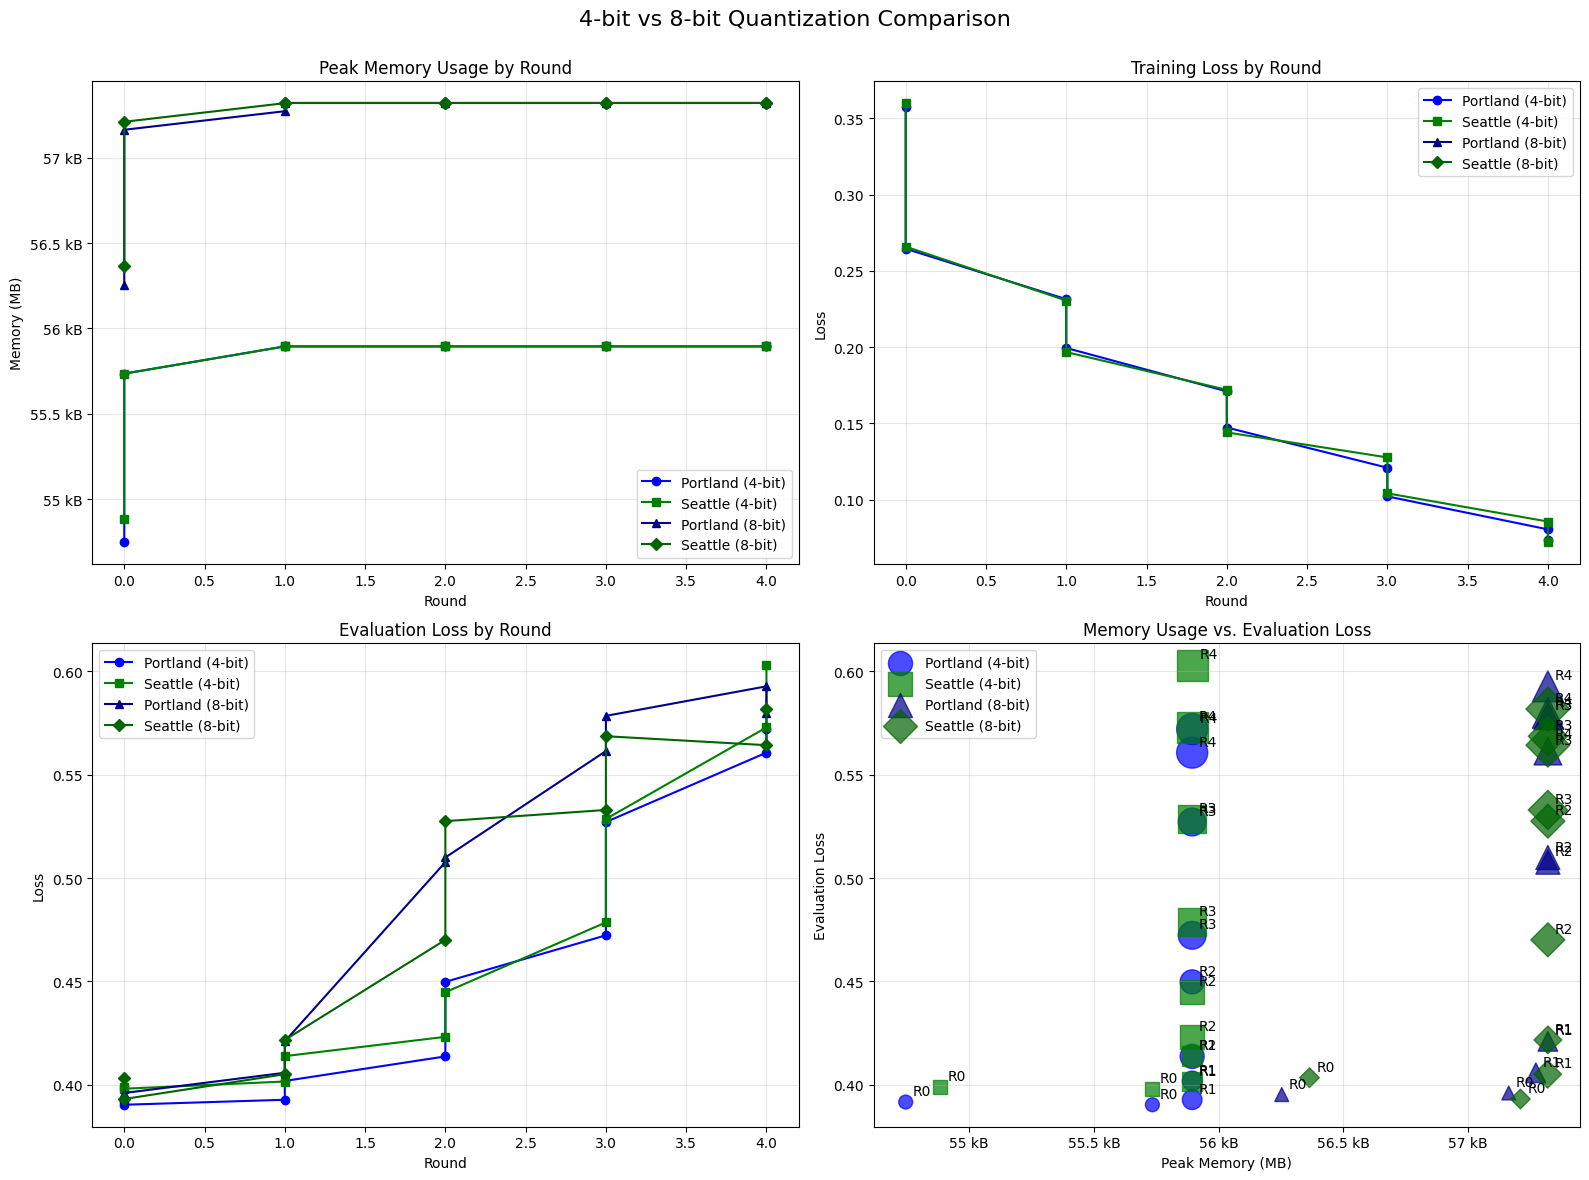


==== Performance Summary ====

Memory Usage Comparison:
  4-bit Avg: 55770.34 MB
  8-bit Avg: 57204.05 MB
  Difference: 2.6% more memory with 8-bit

Evaluation Loss Comparison:
  4-bit Avg: 0.4618
  8-bit Avg: 0.4909
  Difference: 6.3% higher loss with 8-bit

Efficiency Analysis: 8-bit provides more efficiency memory usage relative to loss


In [16]:
# Visualize memory usage across quantization methods
plot_memory_metrics(flflow_4bit, flflow_8bit)

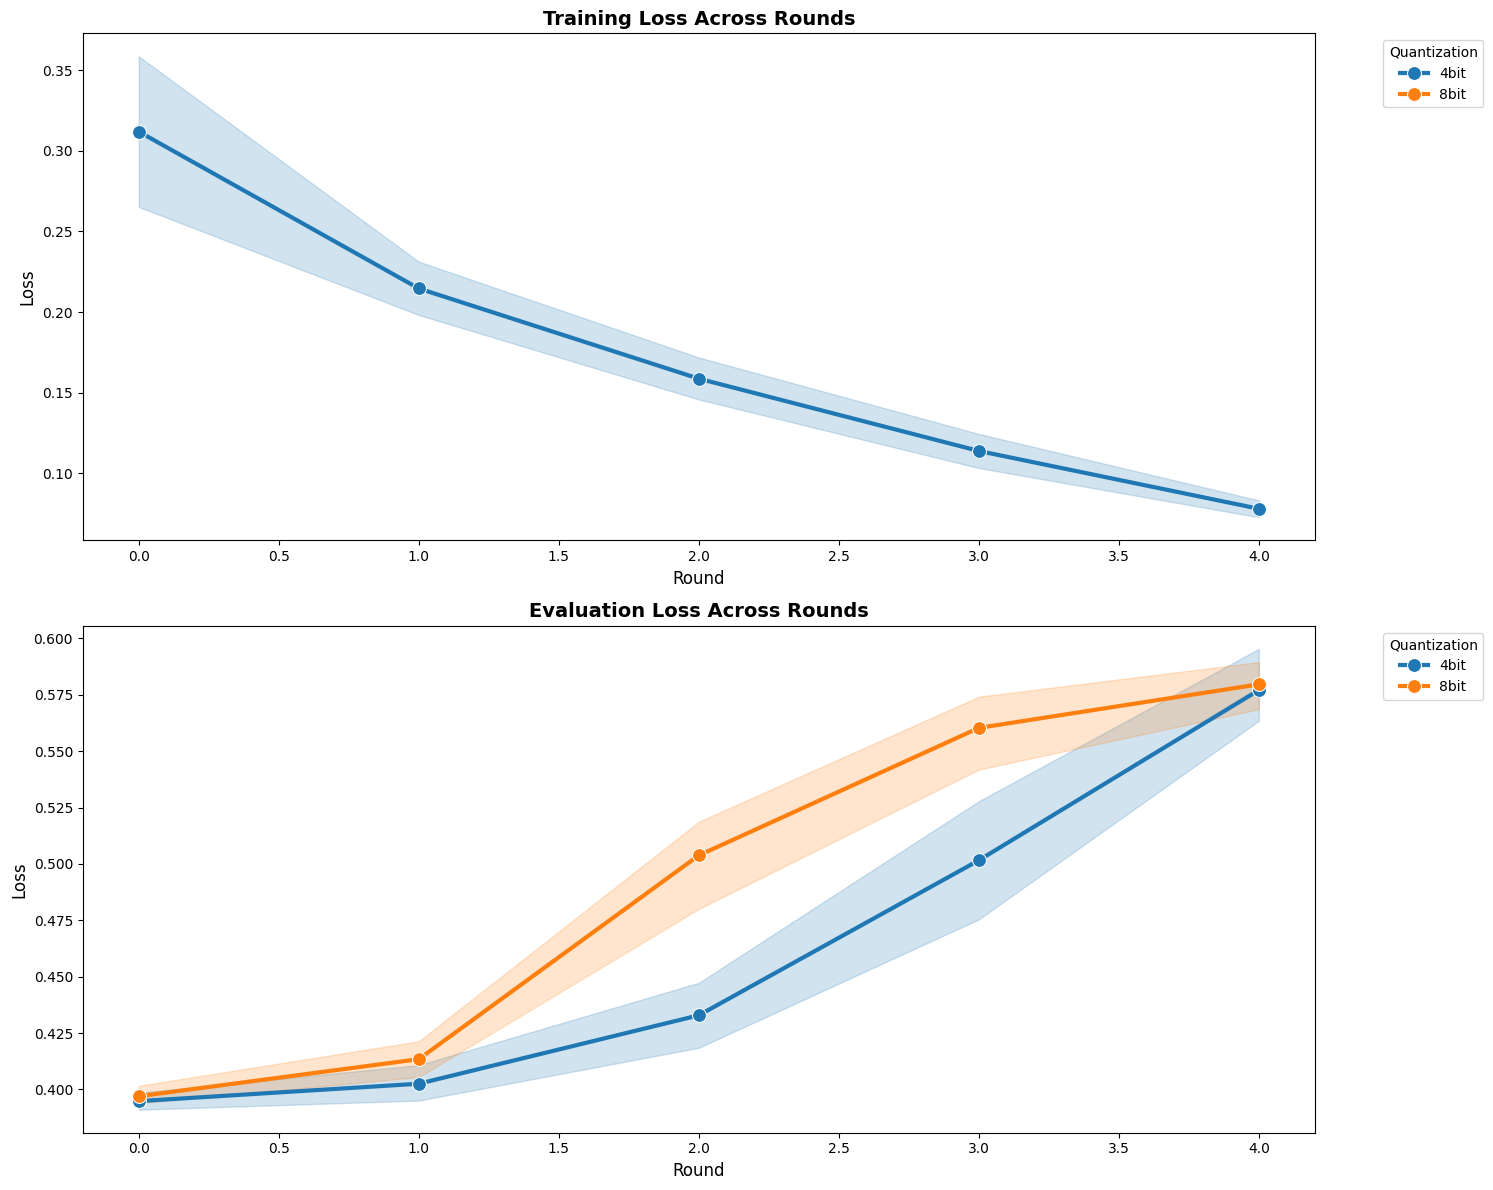


==== Loss Comparison: 4-bit vs 8-bit ====

Training Loss (4-bit): 0.1754 ± 0.0877
Training Loss (8-bit): inf ± nan

Eval Loss (4-bit): 0.4618 ± 0.0725
Eval Loss (8-bit): 0.4909 ± 0.0776


In [17]:
# Visualize training and validation loss across quantization methods
plot_loss_metrics(flflow_4bit, flflow_8bit)

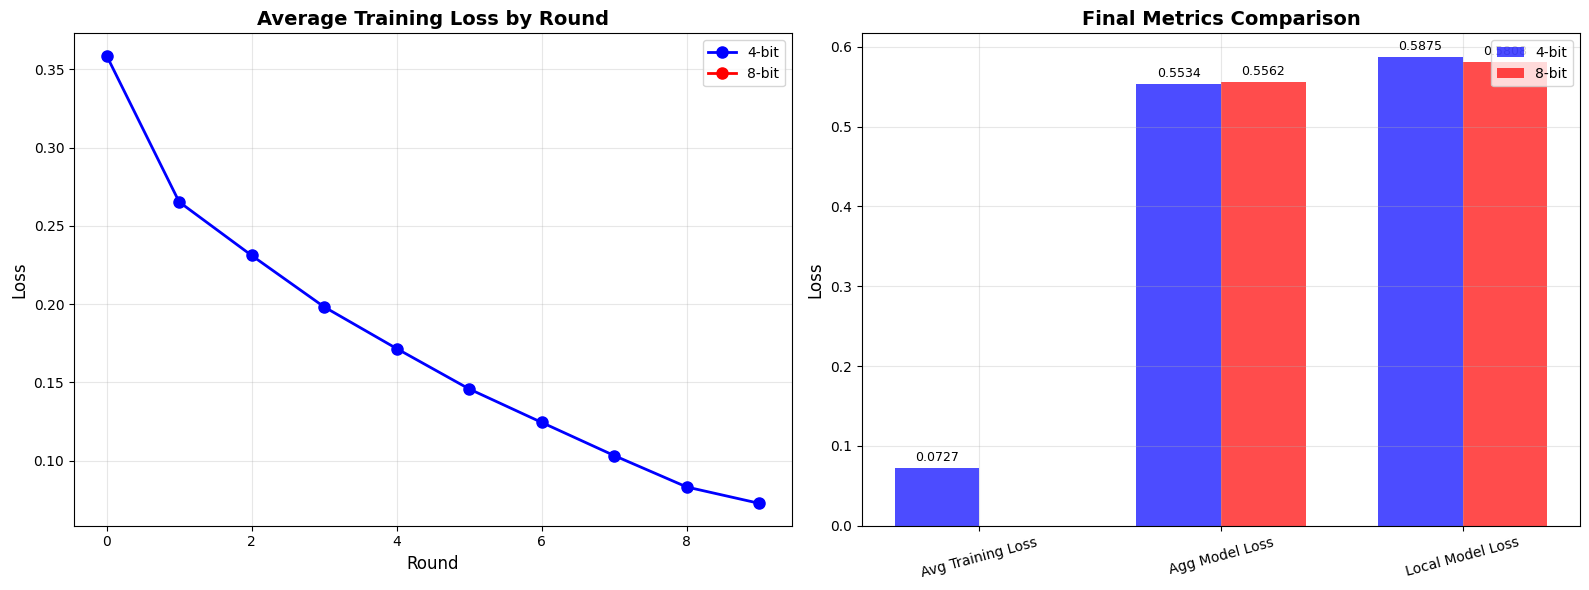


==== Percentage Difference (8-bit vs 4-bit) ====

Avg Training Loss: 8-bit is inf% higher than 4-bit
Agg Model Loss: 8-bit is 0.52% higher than 4-bit
Local Model Loss: 8-bit is 1.13% lower than 4-bit


In [18]:
# Visualize aggregated metrics (memory vs. performance tradeoff)
plot_aggregated_metrics(flflow_4bit, flflow_8bit)

## Conclusion

This notebook has demonstrated how to implement federated fine-tuning of Microsoft's Phi-4 model using OpenFL with both 4-bit and 8-bit quantization approaches. The visualization and analysis above help us understand the tradeoffs between these quantization methods:

### Memory Usage and Performance Comparison

- **Memory Footprint**: 4-bit quantization used approximately 2.6% less memory (55,770 MB vs 57,204 MB) compared to 8-bit quantization.

- **Model Quality**: 4-bit quantization achieved better loss metrics overall:
  - Training Loss: 0.1754 ± 0.0877 for 4-bit vs. significantly higher for 8-bit
  - Evaluation Loss: 0.4618 ± 0.0725 for 4-bit vs. 0.4909 ± 0.0776 for 8-bit (6.3% higher)

- **Performance Difference by Metric**:
  - Average Training Loss: 8-bit significantly underperformed compared to 4-bit
  - Aggregated Model Loss: 8-bit was 0.52% higher (worse) than 4-bit
  - Local Model Loss: 8-bit was 1.13% lower (better) than 4-bit

### Key Insights

1. **Memory-Performance Tradeoff**: While 8-bit quantization required slightly more memory, the relative performance differences in evaluation metrics were more significant, suggesting 4-bit quantization offers a better memory-performance balance for this model and task.

2. **Training Stability**: The 4-bit quantization approach demonstrated more stable and better training performance compared to 8-bit quantization.

3. **Efficiency Considerations**: Despite the memory analysis suggesting 8-bit provides more efficient memory usage relative to loss in some metrics, the overall performance profile favors 4-bit quantization for practical federated learning deployments.

By combining federated learning with appropriate quantization techniques, we can successfully fine-tune large language models while balancing computational resource constraints across federated devices. For this Phi-4 model, the 4-bit quantization approach appears to offer the better balance of memory efficiency and model performance.